In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (accuracy_score,confusion_matrix,ConfusionMatrixDisplay, classification_report,precision_score, recall_score, f1_score,roc_auc_score, RocCurveDisplay)

In [7]:
from google.colab import drive
drive.mount('/content/drive',force_remount=False)

df = pd.read_csv('/content/drive/MyDrive/ML- ArvoreDecisaoPY/Heart_Attack_Data_Set.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df = df.rename(columns={
"age":"idade",
"sex":"sexo",
"cp":"tipo_dor_peito",
"trestbps":"pressao_repouso",
"chol":"colesterol",
"fbs":"glicemia_jejum",
"restecg":"ecg_repouso",
"thalach":"freq_cardiaca_max",
"exang":"angina_exercicio",
"oldpeak":"depressao_st",
"slope":"inclinacao_st",
"ca":"num_vasos",
"thal":"talassemia",
"target" :"desfecho"
})
df.head()

,idade,sexo,tipo_dor_peito,pressao_repouso,colesterol,glicemia_jejum,ecg_repouso,freq_cardiaca_max,angina_exercicio,depressao_st,inclinacao_st,num_vasos,talassemia,desfecho
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [9]:
print(df["desfecho"].value_counts())

desfecho
1    165
0    138
Name: count, dtype: int64


In [10]:
X = df.drop(columns=["desfecho"]) #x recebe todas as colunas exceto, menos a "desfecho" -> variaveis desfecho
y = df["desfecho"] #y recebe só a coluna "desfecho" -> variavel dependente

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
X,y,
test_size=0.20,
random_state=42,#semente
stratify=y) #proporção entre 0 e 1 no treino e no teste

print(f"treino: {X_train.shape[0]} amostras")
print(f"teste : {X_test.shape[0]} amostras")

treino: 242 amostras
teste : 61 amostras


In [12]:
arvore = DecisionTreeClassifier( #criacao da arvore - gini
    max_depth= 5 , #nvl de profundidade
    min_samples_split=5, #o nó so pode ser dividido em 5 amostra
    random_state = 42
)

arvore.fit(X_train,y_train) #treina o modelo

print(f"Num_folhas {arvore.get_n_leaves()}")


Num_folhas 21


In [13]:
y_previsao = arvore.predict(X_test) #usa os dados test para fazer a predict
y_probabilidade = arvore.predict_proba(X_test)[:,1] #pega só com 1

acuracia= accuracy_score(y_test,y_previsao)# %acerto no geral
precisao= precision_score(y_test,y_previsao)#qnts realmente eram
revocacao= recall_score(y_test,y_previsao) #qnts realmente tinham
f1= f1_score(y_test,y_previsao) #equilibrio
auc= roc_auc_score(y_test,y_probabilidade)#separa doentes dos nao-doentes

print(f"acuracia: {acuracia:.3f}")
print(f"precisao: {precisao:.3f}")
print(f"revocacao/recall: {revocacao:.3f}")
print(f"f1-score: {f1:.3f}")
print(f"auc-roc: {auc:.3f}")

print(classification_report(y_test, y_previsao, target_names=["s/ataque", "c/ataque"]))

acuracia: 0.787
precisao: 0.750
revocacao/recall: 0.909
f1-score: 0.822
auc-roc: 0.818
              precision    recall  f1-score   support

    s/ataque       0.86      0.64      0.73        28
    c/ataque       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



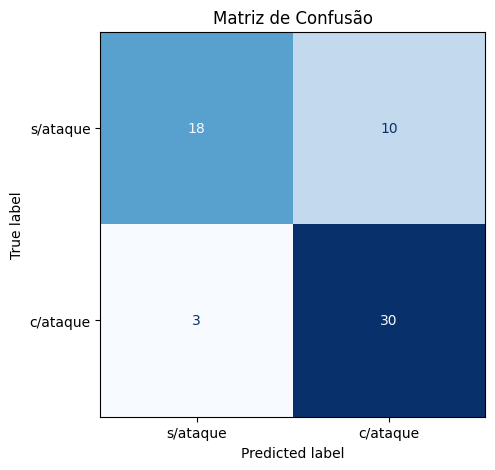

In [14]:
fig, ax = plt.subplots(figsize=(10,5))

mc = confusion_matrix(y_test, y_previsao)

ConfusionMatrixDisplay(mc,display_labels=["s/ataque", "c/ataque"]
).plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("Matriz de Confusão")
plt.show()



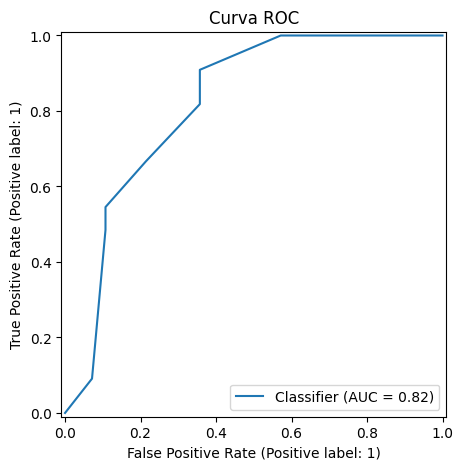

In [15]:
fig, ax = plt.subplots(figsize=(10,5))

RocCurveDisplay.from_predictions(y_test, y_probabilidade,ax=ax)

ax.set_title("Curva ROC")
plt.show()

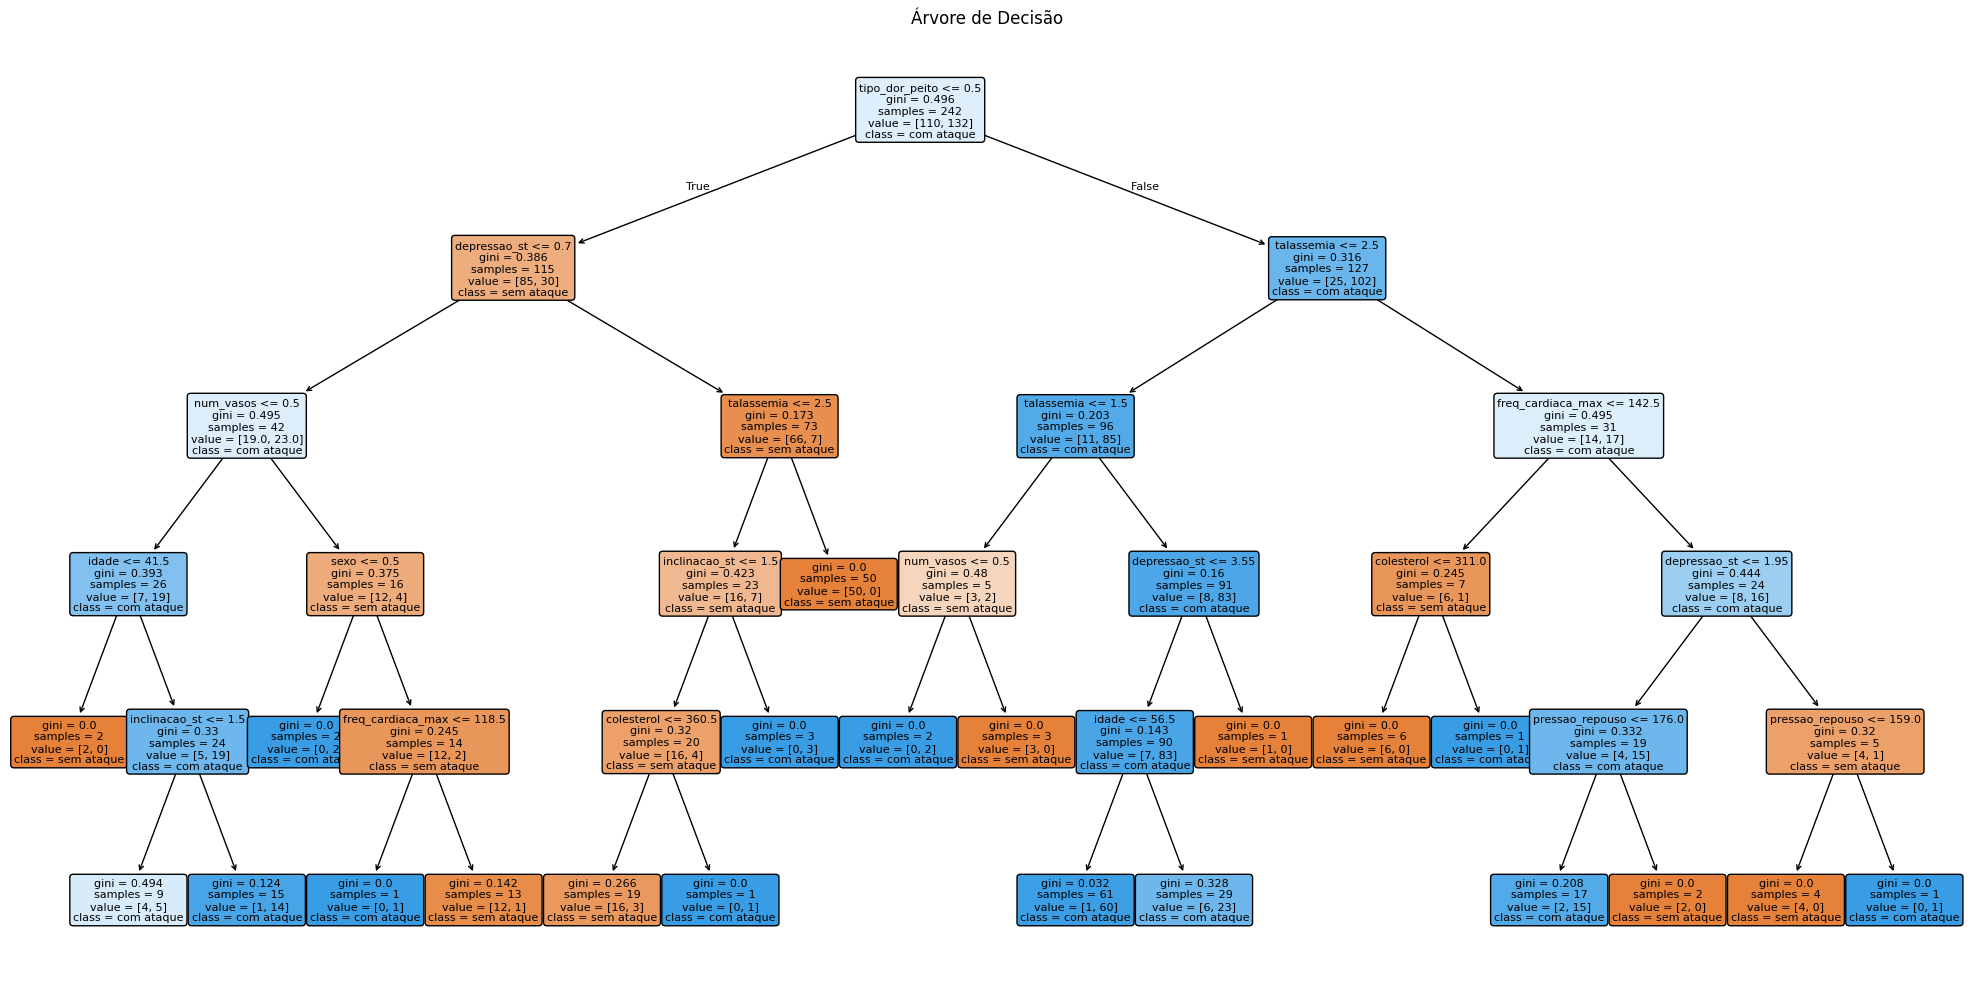

In [20]:
plt.figure(figsize=(20,10))
plot_tree(
    arvore,
    feature_names=X.columns.tolist(),
    class_names=["sem ataque", "com ataque"],
    filled=True,
    rounded=True,
    fontsize=8)

plt.title("Árvore de Decisão")
plt.tight_layout()
plt.show()

In [17]:
parametros = {
    "max_depth":[3, 4, 5, 6, 7],
    "min_samples_split":[2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    parametros,
    cv=5, #divide o treino em 5 partes
    scoring="f1", #criterio
)

grid.fit(X_train, y_train)

print("melhores parâmetros:", grid.best_params_)

arvore_otimi = grid.best_estimator_
y_previsao_otimi = arvore_otimi.predict(X_test)
y_probabilidade_otimi = arvore_otimi.predict_proba(X_test)[:, 1]

print(f"\nhiperparametros ajustados:")
print(f"  acurácia : {accuracy_score(y_test, y_previsao_otimi)*100:.2f}%")
print(f"  f1-score : {f1_score(y_test, y_previsao_otimi)*100:.2f}%")
print(f"  auc-roc  : {roc_auc_score(y_test, y_probabilidade_otimi)*100:.2f}%")

melhores parâmetros: {'max_depth': 3, 'min_samples_split': 2}

hiperparametros ajustados:
  acurácia : 75.41%
  f1-score : 78.26%
  auc-roc  : 81.76%


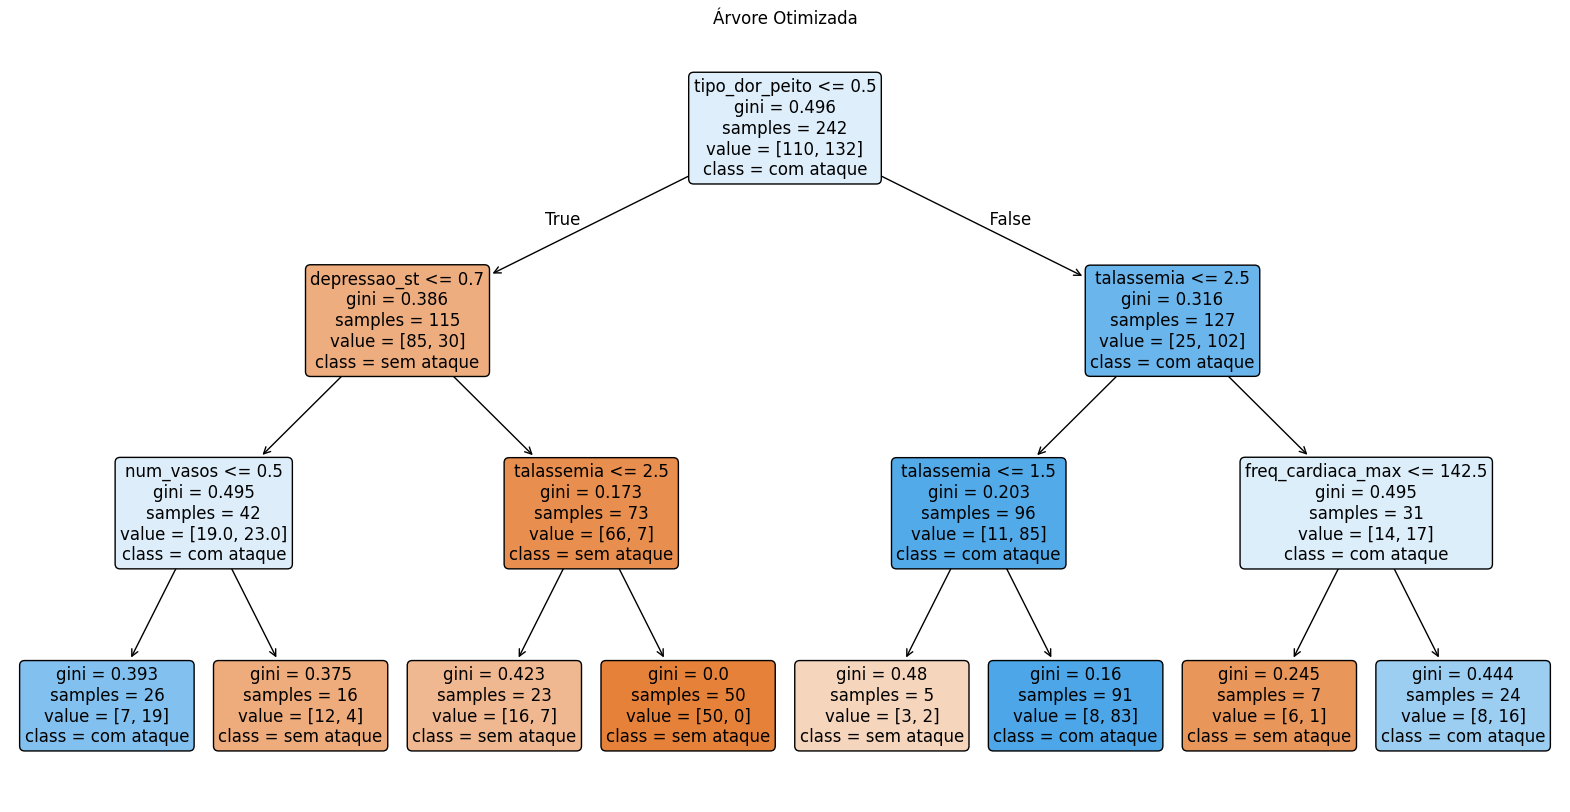

In [18]:
plt.figure(figsize=(20,10))
plot_tree(
    arvore_otimi,
    feature_names=X.columns.tolist(),
    class_names=["sem ataque", "com ataque"],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Árvore Otimizada")
plt.show()

In [19]:
tabela_final = pd.DataFrame({
    "métrica": ["acurácia", "precisão", "revocação", "f1-score", "auc-roc"],

    "árvore de decisão": [
        f"{acuracia*100:.2f}%",
        f"{precisao*100:.2f}%",
        f"{revocacao*100:.2f}%",
        f"{f1*100:.2f}%",
        f"{auc*100:.2f}%"
    ]
})

tabela_final

,métrica,árvore de decisão
0,acurácia,78.69%
1,precisão,75.00%
2,revocação,90.91%
3,f1-score,82.19%
4,auc-roc,81.76%
